In [ ]:
# # Key Terms Used
# # Core terms
# INCLUDE_TERMS = [
#     "optical computing",
#     "optical artificial intelligence",
#     "neuromorphic photonics",
#     "light processing",
#     "light-based processing",
#     "photonic computing",
#     "silicon photonic processing",
#     "optical artificial intelligence",
# ]

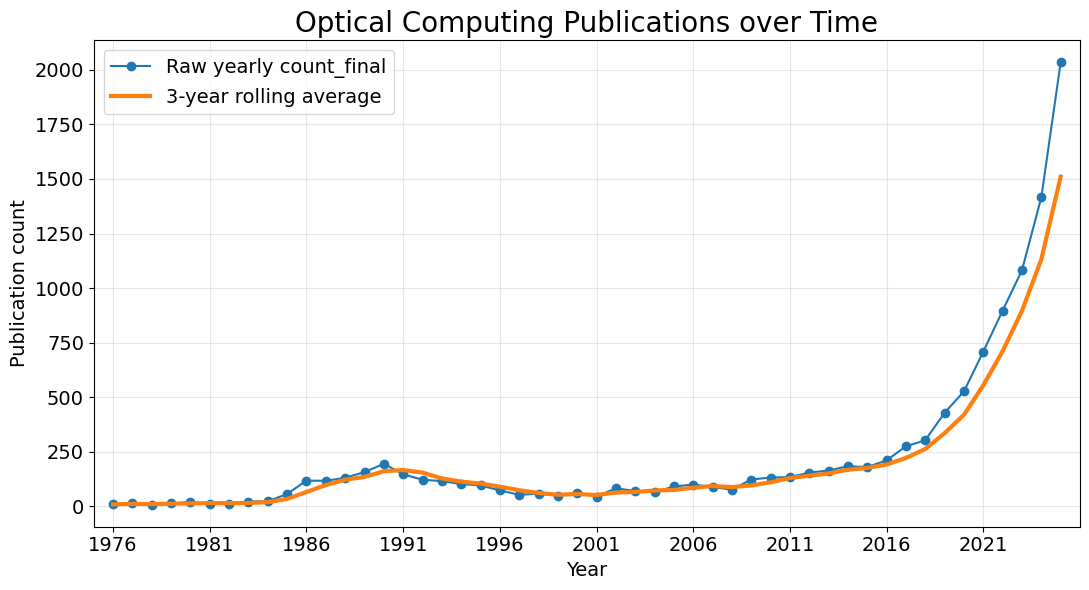

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#Read
data_file = Path("1976-2025.csv")
combined = pd.read_csv(data_file)

# Ensure year is numeric
combined["year"] = pd.to_numeric(combined["year"], errors="coerce")

# Convert all other columns to numeric where possible
numeric_cols = combined.columns.drop("year")
combined[numeric_cols] = combined[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

# Sort and deduplicate
combined = combined.sort_values("year")
combined = combined.drop_duplicates(subset="year", keep="last")

# Choose column to plot
if "count_final" in combined.columns:
    ycol = "count_final"
elif "count" in combined.columns:
    ycol = "count"
else:
    numeric_cols = combined.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "year"]
    if not numeric_cols:
        raise ValueError("Could not find a count column to plot.")
    ycol = numeric_cols[0]

# Drop NaNs 
combined = combined.dropna(subset=["year", ycol])

# --- Rolling average ---
rolling_window = 3
combined[f"{ycol}_rolling_{rolling_window}y"] = (
    combined[ycol].rolling(window=rolling_window, min_periods=1).mean()
)

# --- Plot ---
plt.figure(figsize=(11, 6))
plt.plot(combined["year"], combined[ycol], marker="o", label=f"Raw yearly {ycol}")

if rolling_window > 1:
    plt.plot(
        combined["year"],
        combined[f"{ycol}_rolling_{rolling_window}y"],
        label=f"{rolling_window}-year rolling average", 
        linewidth = 3
    )

plt.xlabel("Year",fontsize =14)
plt.ylabel("Publication count",fontsize =14)
plt.title("Optical Computing Publications over Time", fontsize =20)
plt.xticks(
    ticks=range(int(combined["year"].min()), 2026, 5),  # every 5 years up to 2025
    fontsize=14
)
plt.yticks(fontsize=14)
plt.xlim(1975,2026)
plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "./optPubvsTime.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()